In [1]:
## !pip install prophet 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA 

import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('Profit.csv')

In [4]:
df.head()

,Time Date,Product,Store,Value
0,1012018,2667437,QLD_CW_ST0203,2926.000
1,2012018,2667437,QLD_CW_ST0203,2687.531
2,3012018,2667437,QLD_CW_ST0203,2793.000
3,4012018,2667437,QLD_CW_ST0203,2394.000
4,5012018,2667437,QLD_CW_ST0203,2660.000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Time Date  1080 non-null   int64  
 1   Product    1080 non-null   int64  
 2   Store      1080 non-null   object 
 3   Value      1080 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 33.9+ KB


In [6]:
df['Year']=df['Time Date'].apply(lambda x: str(x)[-4:])

In [7]:
df

,Time Date,Product,Store,Value,Year
0,1012018,2667437,QLD_CW_ST0203,2926.000000,2018
1,2012018,2667437,QLD_CW_ST0203,2687.531000,2018
2,3012018,2667437,QLD_CW_ST0203,2793.000000,2018
3,4012018,2667437,QLD_CW_ST0203,2394.000000,2018
4,5012018,2667437,QLD_CW_ST0203,2660.000000,2018
...,...,...,...,...,...
1075,12122020,2667437,QLD_CW_ST0203,3167.594500,2020
1076,13122020,2667437,QLD_CW_ST0203,3167.594500,2020
1077,14122020,2667437,QLD_CW_ST0203,3383.354511,2020
1078,15122020,2667437,QLD_CW_ST0203,2714.591329,2020


In [8]:
df['Month']=df['Time Date'].apply(lambda x: str(x)[-6:-4])
df['Date']=df['Time Date'].apply(lambda x: str(x)[:-6])


In [9]:
df

,Time Date,Product,Store,Value,Year,Month,Date
0,1012018,2667437,QLD_CW_ST0203,2926.000000,2018,01,1
1,2012018,2667437,QLD_CW_ST0203,2687.531000,2018,01,2
2,3012018,2667437,QLD_CW_ST0203,2793.000000,2018,01,3
3,4012018,2667437,QLD_CW_ST0203,2394.000000,2018,01,4
4,5012018,2667437,QLD_CW_ST0203,2660.000000,2018,01,5
...,...,...,...,...,...,...,...
1075,12122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,12
1076,13122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,13
1077,14122020,2667437,QLD_CW_ST0203,3383.354511,2020,12,14
1078,15122020,2667437,QLD_CW_ST0203,2714.591329,2020,12,15


In [10]:
df['Formatted_Date']=pd.to_datetime(df['Year']+'-'+df['Month']+'-'+df['Date'])

In [11]:
df

,Time Date,Product,Store,Value,Year,Month,Date,Formatted_Date
0,1012018,2667437,QLD_CW_ST0203,2926.000000,2018,01,1,2018-01-01
1,2012018,2667437,QLD_CW_ST0203,2687.531000,2018,01,2,2018-01-02
2,3012018,2667437,QLD_CW_ST0203,2793.000000,2018,01,3,2018-01-03
3,4012018,2667437,QLD_CW_ST0203,2394.000000,2018,01,4,2018-01-04
4,5012018,2667437,QLD_CW_ST0203,2660.000000,2018,01,5,2018-01-05
...,...,...,...,...,...,...,...,...
1075,12122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,12,2020-12-12
1076,13122020,2667437,QLD_CW_ST0203,3167.594500,2020,12,13,2020-12-13
1077,14122020,2667437,QLD_CW_ST0203,3383.354511,2020,12,14,2020-12-14
1078,15122020,2667437,QLD_CW_ST0203,2714.591329,2020,12,15,2020-12-15


In [12]:
df.drop(['Time Date', 'Product', 'Store', 'Year', 'Month', 'Date'], axis=1, inplace=True)

In [13]:
df.columns=['Value','Formatted Date']

In [14]:
df

,Value,Formatted Date
0,2926.000000,2018-01-01
1,2687.531000,2018-01-02
2,2793.000000,2018-01-03
3,2394.000000,2018-01-04
4,2660.000000,2018-01-05
...,...,...
1075,3167.594500,2020-12-12
1076,3167.594500,2020-12-13
1077,3383.354511,2020-12-14
1078,2714.591329,2020-12-15


In [15]:
df2=df.copy()

In [16]:
df.set_index('Formatted Date',inplace=True)

In [17]:
df

,Value
Formatted Date,
2018-01-01,2926.000000
2018-01-02,2687.531000
2018-01-03,2793.000000
2018-01-04,2394.000000
2018-01-05,2660.000000
...,...
2020-12-12,3167.594500
2020-12-13,3167.594500
2020-12-14,3383.354511


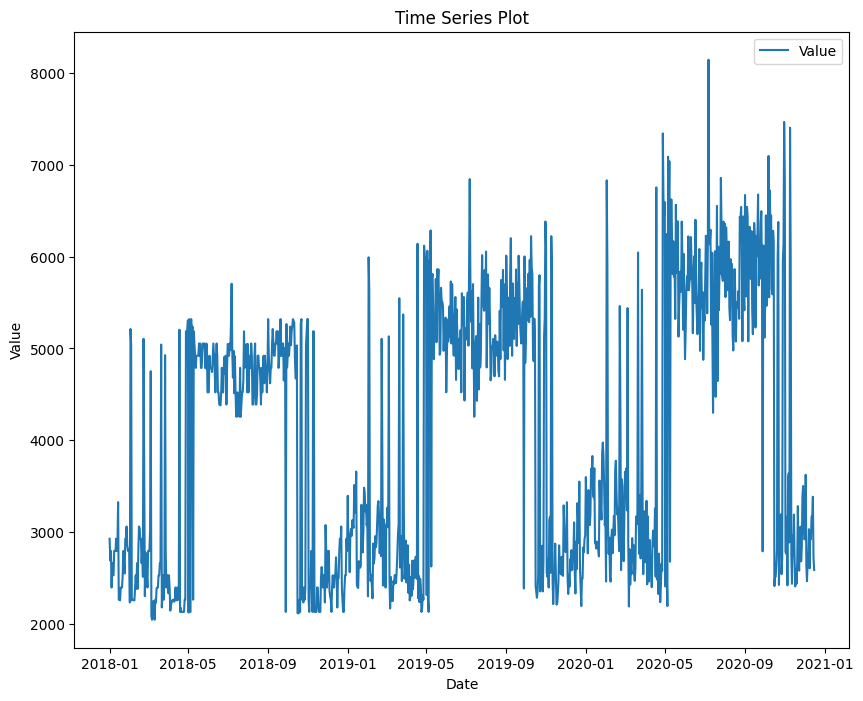

In [18]:
plt.figure(figsize=(10,8))
plt.plot(df.index, df.Value, label='Value')

plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Value')

plt.legend()
plt.show()

## ADF Test

In [19]:
result = adfuller(df['Value']) 
print(result)
print('P - Value: ',result[1])


(-2.2124789527936, 0.20174753235777315, 22, 1057, {'1%': -3.4365517520261637, '5%': -2.86427826065702, '10%': -2.5682279541355597}, 17192.852381178156)
P - Value:  0.20174753235777315


In [20]:
if(result[1] > 0.05) :
    df['Value_Diff'] = df['Value'].diff().dropna()
else:
    print('The series is stationary. Proceeding without differencing.')

In [21]:
df

,Value,Value_Diff
Formatted Date,,
2018-01-01,2926.000000,NaN
2018-01-02,2687.531000,-238.469000
2018-01-03,2793.000000,105.469000
2018-01-04,2394.000000,-399.000000
2018-01-05,2660.000000,266.000000
...,...,...
2020-12-12,3167.594500,245.956900
2020-12-13,3167.594500,0.000000
2020-12-14,3383.354511,215.760011


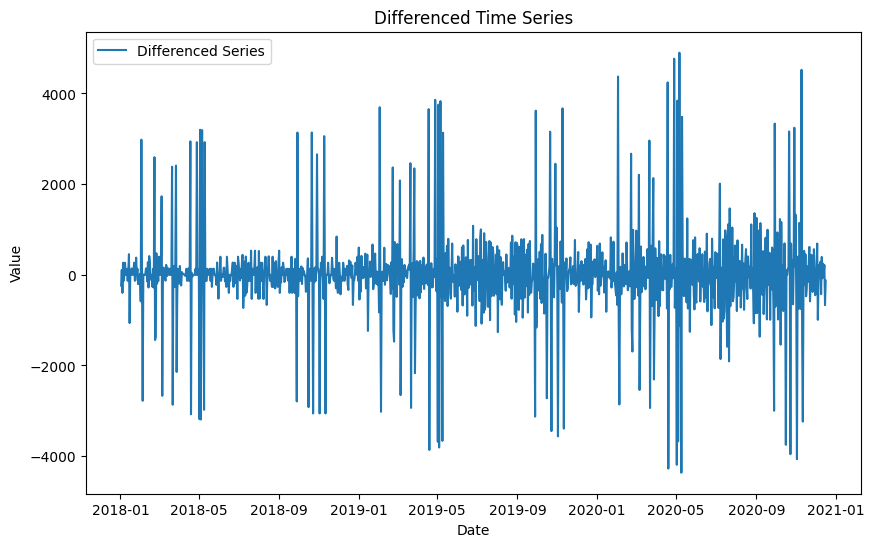

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(df['Value_Diff'], label='Differenced Series')
plt.title('Differenced Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [23]:
df.drop(df.index[0],inplace=True)

In [24]:
df

,Value,Value_Diff
Formatted Date,,
2018-01-02,2687.531000,-238.469000
2018-01-03,2793.000000,105.469000
2018-01-04,2394.000000,-399.000000
2018-01-05,2660.000000,266.000000
2018-01-06,2527.000000,-133.000000
...,...,...
2020-12-12,3167.594500,245.956900
2020-12-13,3167.594500,0.000000
2020-12-14,3383.354511,215.760011


In [25]:
result_diff = adfuller(df['Value_Diff'])
print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])

if result_diff[1] > 0.05:
    print("The differenced series is still not stationary.")
else:
    print("The differenced series is stationary. Ready for ARIMA modeling.")


ADF Statistic (Differenced): -9.498547019850033
p-value (Differenced): 3.4952395496433544e-16
The differenced series is stationary. Ready for ARIMA modeling.


In [26]:
df=df.drop('Value_Diff', axis=1)

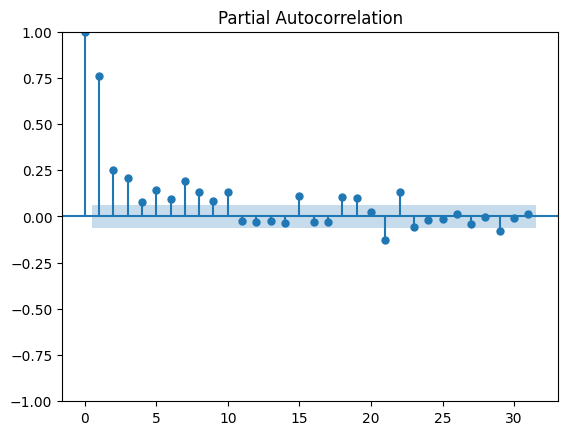

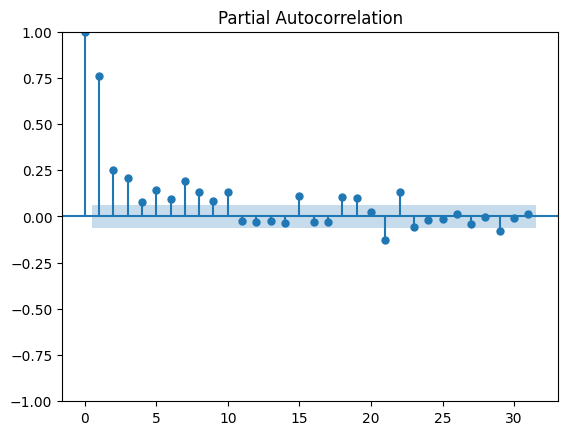

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

series = df['Value']   # time series column
plot_pacf(series)

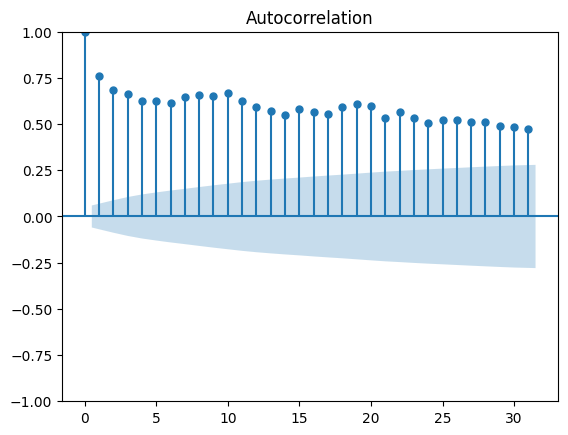

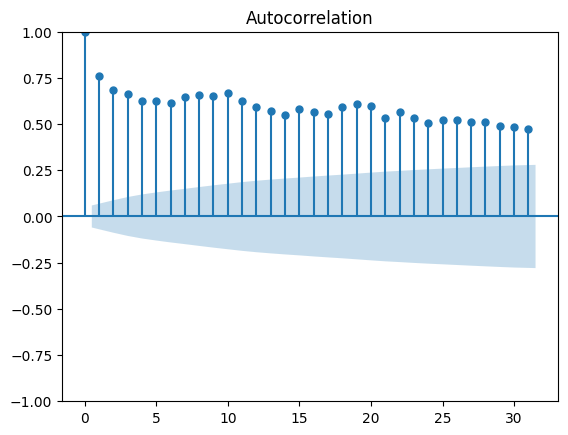

In [28]:
plot_acf(series)

## Define ARIMA Parameters

In [29]:
df = df.asfreq('D')
print(df.index.freq)

<Day>


In [30]:
p,d,q = 2,1,2

arima_model = ARIMA(df['Value'],order=(p,d,q)) 
arima_fitted = arima_model.fit()


In [31]:
print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                 1080
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -8796.609
Date:                Fri, 13 Mar 2026   AIC                          17603.218
Time:                        16:26:53   BIC                          17628.137
Sample:                    01-02-2018   HQIC                         17612.654
                         - 12-16-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4786      0.145     -3.298      0.001      -0.763      -0.194
ar.L2          0.1836      0.056      3.290      0.001       0.074       0.293
ma.L1         -0.0926      0.145     -0.638      0.5

## Forecast Future Values

In [32]:
forecast_steps = 20
forecast = arima_fitted.forecast(steps=forecast_steps)

In [33]:
print("ARIMA Forecast:\n",forecast)

ARIMA Forecast:
 2020-12-17    2844.786816
2020-12-18    2885.430655
2020-12-19    2913.668865
2020-12-20    2907.615736
2020-12-21    2915.697541
2020-12-22    2910.718022
2020-12-23    2914.585186
2020-12-24    2911.820012
2020-12-25    2913.853515
2020-12-26    2912.372536
2020-12-27    2913.454726
2020-12-28    2912.664851
2020-12-29    2913.241598
2020-12-30    2912.820530
2020-12-31    2913.127956
2021-01-01    2912.903505
2021-01-02    2913.067377
2021-01-03    2912.947734
2021-01-04    2913.035085
2021-01-05    2912.971310
Freq: D, Name: predicted_mean, dtype: float64


## Prophet

In [34]:
df2.head()

,Value,Formatted Date
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [35]:
df2.columns=['y','ds']

In [36]:
df2.head()

,y,ds
0,2926.000,2018-01-01
1,2687.531,2018-01-02
2,2793.000,2018-01-03
3,2394.000,2018-01-04
4,2660.000,2018-01-05


In [45]:
m=Prophet(interval_width=0.95, daily_seasonality=True)

In [46]:
m.fit(df2)

16:34:40 - cmdstanpy - INFO - Chain [1] start processing
16:34:41 - cmdstanpy - INFO - Chain [1] done processing


## Forecast

In [47]:
future = m.make_future_dataframe(periods=1000,freq='D')

In [48]:
forecast = m.predict(future)

In [49]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-01-01,3042.707031,758.206841,3902.170176,3042.707031,3042.707031,-636.756103,-636.756103,-636.756103,472.567854,...,16.615615,16.615615,16.615615,-1125.939571,-1125.939571,-1125.939571,0.0,0.0,0.0,2405.950928
1,2018-01-02,3043.438906,752.376356,4124.114174,3043.438906,3043.438906,-646.926343,-646.926343,-646.926343,472.567854,...,-11.291457,-11.291457,-11.291457,-1108.202740,-1108.202740,-1108.202740,0.0,0.0,0.0,2396.512563
2,2018-01-03,3044.170781,846.527591,4134.325787,3044.170781,3044.170781,-621.142084,-621.142084,-621.142084,472.567854,...,-4.423814,-4.423814,-4.423814,-1089.286123,-1089.286123,-1089.286123,0.0,0.0,0.0,2423.028697
3,2018-01-04,3044.902656,816.889998,4039.333437,3044.902656,3044.902656,-574.199279,-574.199279,-574.199279,472.567854,...,22.497906,22.497906,22.497906,-1069.265039,-1069.265039,-1069.265039,0.0,0.0,0.0,2470.703376
4,2018-01-05,3045.634530,861.066816,3975.092863,3045.634530,3045.634530,-610.265676,-610.265676,-610.265676,472.567854,...,-34.566045,-34.566045,-34.566045,-1048.267484,-1048.267484,-1048.267484,0.0,0.0,0.0,2435.368855


In [50]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
2075,2023-09-08,6905.021308,5342.882743,8452.879825
2076,2023-09-09,6929.254528,5342.336150,8564.508953
2077,2023-09-10,6973.764520,5398.831919,8550.666867
2078,2023-09-11,6972.234853,5358.110354,8642.136887
2079,2023-09-12,6953.152084,5323.978168,8456.427406


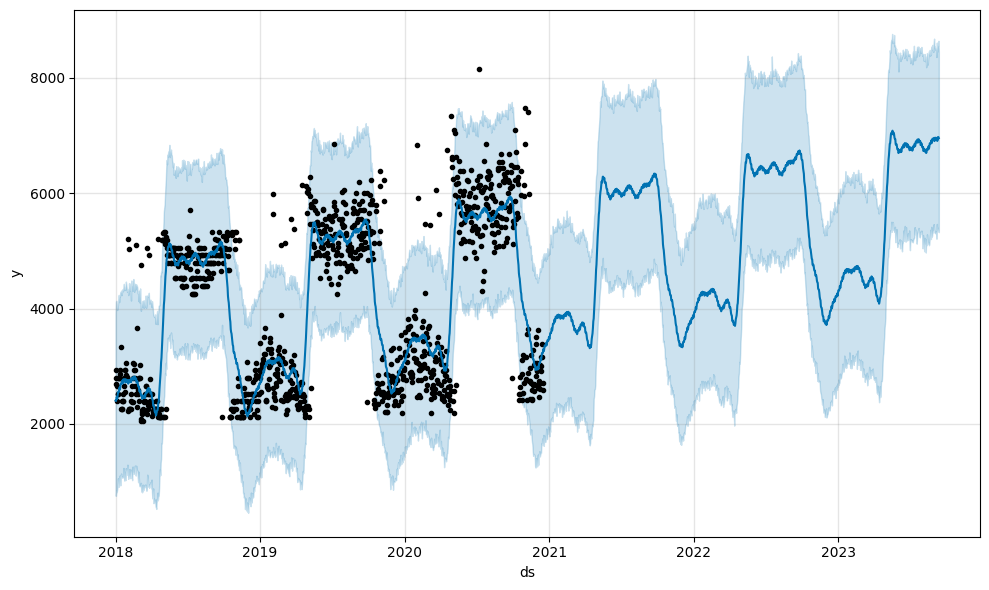

In [51]:
fig = m.plot(forecast)

In [52]:
specific_date = forecast[forecast['ds']== '2023-01-01']

In [53]:
specific_date

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1825,2023-01-01,4944.047069,2768.585409,6006.617329,4874.566813,5016.257792,-632.430847,-632.430847,-632.430847,472.567854,...,25.187112,25.187112,25.187112,-1130.185813,-1130.185813,-1130.185813,0.0,0.0,0.0,4311.616222
